In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. 파일 불러오기 (인코딩은 상황에 맞게 'euc-kr' 또는 'utf-8' 선택)
# 구글 시트에서 저장한 파일이라면 보통 'utf-8'입니다.
df = pd.read_csv('./data/real_estate_total.csv', encoding='euc-kr', parse_dates=["계약일"])
df

C:\Users\gorhk\AppData\Local\Temp\ipykernel_52164\2793908273.py:9: DtypeWarning: Columns (19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/real_estate_total.csv', encoding='euc-kr', parse_dates=["계약일"])


,접수연도,자치구코드,자치구명,법정동코드,법정동명,지번구분,지번구분명,본번,부번,건물명,...,물건금액(만원),건물면적(㎡),토지면적(㎡),층,권리구분,취소일,건축년도,건물용도,신고구분,신고한_개업공인중개사_시군구명
0,2018,11500,강서구,10300,화곡동,1.0,대지,1159.0,0.0,"우장산아이파크,이편한세상",...,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN,NaN
1,2018,11410,서대문구,11200,대현동,1.0,대지,144.0,0.0,럭키대현,...,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN,NaN
2,2018,11590,동작구,10700,사당동,1.0,대지,169.0,32.0,현대,...,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN,NaN
3,2018,11350,노원구,10500,상계동,1.0,대지,1380.0,4.0,초산빌라,...,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN,NaN
4,2018,11380,은평구,11000,증산동,1.0,대지,189.0,63.0,궁전맨션(189-63),...,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833610,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833611,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833612,2024,11440,마포구,11000,노고산동,NaN,NaN,NaN,NaN,NaN,...,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN,NaN


In [5]:
pd.set_option('display.max_columns', None) # 컬럼 생략 금지
pd.set_option('display.max_rows', 200) # 행 100개까지 표시
pd.options.display.float_format='{:.0f}'.format

In [6]:
system_name = platform.system()
if system_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif system_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

In [7]:
# 2. 변경할 컬럼 매핑 딕셔너리 생성
# { "기존 한글명": "변경할 영어명" }
rename_dict = {
    "접수연도": "RCPT_YR",
    "자치구코드": "CGG_CD",
    "자치구명": "CGG_NM",
    "법정동코드": "STDG_CD",
    "법정동명": "STDG_NM",
    "지번구분": "LOTNO_SE",
    "지번구분명": "LOTNO_SE_NM",
    "본번": "MNO",
    "부번": "SNO",
    "건물명": "BLDG_NM",
    "계약일": "CTRT_DAY",
    "물건금액(만원)": "THING_AMT",
    "건물면적(㎡)": "ARCH_AREA",
    "토지면적(㎡)": "LAND_AREA",
    "층": "FLR",
    "권리구분": "RGHT_SE",
    "취소일": "RTRCN_DAY",
    "건축년도": "ARCH_YR",
    "건물용도": "BLDG_USG",
    "신고구분": "DCLR_SE",
    "신고한_개업공인중개사_시군구명": "OPBIZ_RESTAGNT_SGG_NM"
}

# 3. 컬럼명 변경 적용
df = df.rename(columns=rename_dict)

# 4. 제거할 열 리스트 (여기 적힌 열들이 삭제됩니다)
excluded_columns = [
    "RCPT_YR", "LOTNO_SE_NM", "MNO", "SNO", "OPBIZ_RESTAGNT_SGG_NM"
]
# 열 삭제 실행 (axis=1은 열을 의미합니다)
df_final = df.drop(columns=excluded_columns)

# 5. 결과 저장 (DBeaver 업로드용 UTF-8)
# df_final.to_csv('data/real_estate_total_edit.csv', index=False, encoding='cp949')


In [8]:
# 앞으로 사용할 데이터프레임 새로 생성
df2 = df.copy()
df2

,RCPT_YR,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,LOTNO_SE_NM,MNO,SNO,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,OPBIZ_RESTAGNT_SGG_NM
0,2018,11500,강서구,10300,화곡동,1,대지,1159,0,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,NaN,2008,아파트,NaN,NaN
1,2018,11410,서대문구,11200,대현동,1,대지,144,0,럭키대현,2019-03-16,70000,83,NaN,10,NaN,NaN,1999,아파트,NaN,NaN
2,2018,11590,동작구,10700,사당동,1,대지,169,32,현대,2019-02-21,49500,52,NaN,10,NaN,NaN,1991,아파트,NaN,NaN
3,2018,11350,노원구,10500,상계동,1,대지,1380,4,초산빌라,2019-01-21,16000,41,18,1,NaN,NaN,1996,연립다세대,NaN,NaN
4,2018,11380,은평구,11000,증산동,1,대지,189,63,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,NaN,1992,연립다세대,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,2024,11530,구로구,10700,개봉동,1,대지,170,33,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래,서울 강남구
833610,2024,11530,구로구,10700,개봉동,1,대지,170,33,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래,서울 강남구
833611,2024,11530,구로구,10700,개봉동,1,대지,170,33,금석연립(170-33),2022-07-08,9740,54,124,2,NaN,20240207,1981,연립다세대,중개거래,서울 강남구
833612,2024,11440,마포구,11000,노고산동,NaN,NaN,NaN,NaN,NaN,2021-07-19,195000,157,117,NaN,NaN,20240417,1988,단독다가구,NaN,NaN


In [9]:
df2['CTRT_DAY'] = pd.to_datetime(df2['CTRT_DAY'])

df2 = df2[~(
    (df2['CTRT_DAY'].dt.year == 2024) &
    (df2['CTRT_DAY'].dt.month == 10)
)]

In [10]:
# 날짜 컬럼을 datetime 형식으로 변환 (필수!)
df2['CTRT_DAY'] = pd.to_datetime(df2['CTRT_DAY'])

# 계약 연도 컬럼 새로 생성
df2['CTRT_YEAR'] = df2['CTRT_DAY'].dt.year 

# 계약일 연도값별로 개수 count 하고 연도 순서대로 정렬
print(df2['CTRT_DAY'].dt.year.value_counts().sort_index())
'''
CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     13360
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64
'''

CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     13360
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     74828
Name: count, dtype: int64


C:\Users\gorhk\AppData\Local\Temp\ipykernel_52164\1974712697.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['CTRT_DAY'] = pd.to_datetime(df2['CTRT_DAY'])
C:\Users\gorhk\AppData\Local\Temp\ipykernel_52164\1974712697.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['CTRT_YEAR'] = df2['CTRT_DAY'].dt.year


'\nCTRT_DAY\n2008         2\n2009         1\n2010         1\n2011         2\n2012         2\n2013         3\n2014         3\n2015         7\n2016        64\n2017     13360\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n'

In [11]:
# 2018년부터 2024년까지 리스트 설정
target_years = list(range(2018, 2025))

# 해당 연도에 포함되는 데이터만 남기고 copy
df2 = df2[df2['CTRT_DAY'].dt.year.isin(target_years)].copy()

# 필터링 잘 되었는지 결과 확인 
print(df2['CTRT_DAY'].dt.year.value_counts().sort_index())

# 전체 행 수 확인
print(f"\n최종 남은 데이터 건수: {len(df2):,}건")

'''
CTRT_DAY
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64

최종 남은 데이터 건수: 820,169건
'''

CTRT_DAY
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     74828
Name: count, dtype: int64

최종 남은 데이터 건수: 819,272건


'\nCTRT_DAY\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n\n최종 남은 데이터 건수: 820,169건\n'

In [12]:
# 지번구분 열 삭제
df2 = df2.drop(columns= 'LOTNO_SE')
df2

,RCPT_YR,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE_NM,MNO,SNO,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,OPBIZ_RESTAGNT_SGG_NM,CTRT_YEAR
0,2018,11500,강서구,10300,화곡동,대지,1159,0,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,NaN,2008,아파트,NaN,NaN,2019
1,2018,11410,서대문구,11200,대현동,대지,144,0,럭키대현,2019-03-16,70000,83,NaN,10,NaN,NaN,1999,아파트,NaN,NaN,2019
2,2018,11590,동작구,10700,사당동,대지,169,32,현대,2019-02-21,49500,52,NaN,10,NaN,NaN,1991,아파트,NaN,NaN,2019
3,2018,11350,노원구,10500,상계동,대지,1380,4,초산빌라,2019-01-21,16000,41,18,1,NaN,NaN,1996,연립다세대,NaN,NaN,2019
4,2018,11380,은평구,11000,증산동,대지,189,63,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,NaN,1992,연립다세대,NaN,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,2024,11530,구로구,10700,개봉동,대지,170,33,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래,서울 강남구,2022
833610,2024,11530,구로구,10700,개봉동,대지,170,33,금석연립(170-33),2022-07-08,9190,54,124,1,NaN,20240207,1981,연립다세대,중개거래,서울 강남구,2022
833611,2024,11530,구로구,10700,개봉동,대지,170,33,금석연립(170-33),2022-07-08,9740,54,124,2,NaN,20240207,1981,연립다세대,중개거래,서울 강남구,2022
833612,2024,11440,마포구,11000,노고산동,NaN,NaN,NaN,NaN,2021-07-19,195000,157,117,NaN,NaN,20240417,1988,단독다가구,NaN,NaN,2021


In [13]:
# 자치구명 결측치 제거
df2 = df2.dropna(subset=['CGG_NM'])

In [14]:
# 취소일(RTRCN_DAY)이 있는 행 제거
df2 = df2[df2["RTRCN_DAY"].isna()].copy()
df2 = df2.drop(columns=["RTRCN_DAY"])

In [15]:
# 건축년도가 NULL인 데이터 필터링
null_build_df = df2[df2['ARCH_YR'].isnull()]

# 권리구분별 빈도수 계산
counts = null_build_df[['CGG_NM', 'STDG_NM','BLDG_NM','BLDG_USG']].value_counts(dropna=False)

# 빈도수가 30개 이상인 항목만 필터링하여 출력
print(counts[counts >= 30])


CGG_NM  STDG_NM  BLDG_NM        BLDG_USG
송파구     문정동      파크하비오          오피스텔        1505
                 엠스테이트          오피스텔         208
동대문구    용두동      동대문 푸르지오시티     오피스텔         157
용산구     한강로2가    래미안 용산 더 센트럴   오피스텔         144
송파구     방이동      대명벨리온          오피스텔         110
마포구     신공덕동     갑을명가시티2        오피스텔          91
도봉구     도봉동      도봉 투웨니퍼스트 2단지  오피스텔          79
마포구     신공덕동     갑을명가시티1        오피스텔          49
동대문구    장안동      동트리움 에이동       오피스텔          40
                 동트리움 비동        오피스텔          40
송파구     신천동      롯데월드타워앤드롯데월드몰  오피스텔          40
        석촌동      석촌호수 나인파크 A    오피스텔          39
은평구     진관동      은평헤스티아 2차      오피스텔          37
송파구     석촌동      석촌호수 나인파크 B    오피스텔          35
중구      황학동      주건축물제1동        오피스텔          34
Name: count, dtype: int64


In [16]:
# 업데이트할 정밀 단지 정보 리스트 (자치구, 법정동, 본번, 부번, 건물명, 건물용도, 건축년도)
build_info = [
    ('송파구', '문정동', '파크하비오', '오피스텔', 2016),
    ('송파구', '문정동', '엠스테이트', '오피스텔', 2016),
    ('동대문구', '용두동', '동대문 푸르지오시티', '오피스텔', 2016),
    ('용산구', '한강로2가', '래미안 용산 더 센트럴', '오피스텔', 2017),
    ('송파구', '방이동', '대명벨리온', '오피스텔', 2017),
    ('마포구', '신공덕동', '갑을명가시티2', '오피스텔', 2016),
    ('도봉구', '도봉동', '도봉 투웨니퍼스트 2단지', '오피스텔', 2017)
]

# 반복문을 통해 모든 조건을 만족하는 행의 건축년도 업데이트
for gu, dong, bldg, usage, year in build_info:
    condition = (
        (df2['CGG_NM'] == gu) & 
        (df2['STDG_NM'] == dong) & 
        (df2['BLDG_NM'] == bldg) & 
        (df2['BLDG_USG'] == usage) &
        (df2['ARCH_YR'].isnull())
    )
    df2.loc[condition, 'ARCH_YR'] = year

# 업데이트 후에도 남아있는 결측치를 9999로 채우기 (핵심!)
df2['ARCH_YR'] = df2['ARCH_YR'].fillna(9999)

# 실수형(float)을 정수형(int)으로 변환해서 보기 좋게 만들기
df2['ARCH_YR'] = df2['ARCH_YR'].astype(int)


In [17]:
# 1. 데이터 로드
df_ref = pd.read_csv('data/법정동합본.csv', encoding='euc-kr')

# 컬럼명 및 데이터 타입 정리
df_ref.columns = ['CGG_CD', 'CGG_NM', 'STDG_CD', 'STDG_NM']
cols_to_str = ['CGG_CD', 'STDG_CD']
for col in cols_to_str:
    df_ref[col] = df_ref[col].astype(str)
    df2[col] = df2[col].astype(str)

# 2. 매퍼(Mapper) 생성
# 자치구 매퍼
gu_mapper = dict(zip(df_ref['CGG_CD'], df_ref['CGG_NM']))

# 법정동 매퍼 (Key: 구코드 + 동코드)
df_ref['key'] = df_ref['CGG_CD'] + df_ref['STDG_CD']
df2['key'] = df2['CGG_CD'] + df2['STDG_CD']
dong_mapper = dict(zip(df_ref['key'], df_ref['STDG_NM']))

# 3. 데이터 필터링 (불일치/미매핑 즉시 제거)
# 매핑된 정답 이름을 가져와서 원본과 비교합니다.
# (조건: 자치구명 일치 AND 법정동명 일치)
# map 결과가 NaN이거나 이름이 다르면 조건문에서 False가 되어 자동으로 제거됩니다.
initial_count = len(df2)

df2 = df2[
    (df2['CGG_NM'] == df2['CGG_CD'].map(gu_mapper)) & 
    (df2['STDG_NM'] == df2['key'].map(dong_mapper))
].copy()

# 4. 후처리 (임시 컬럼 삭제 및 결과 확인)
df2 = df2.drop(columns=['key'])

print(f"처리 완료: 총 {initial_count}건 중 {initial_count - len(df2)}건 삭제됨 (남은 데이터: {len(df2)}건)")
df2.head()

처리 완료: 총 793749건 중 21건 삭제됨 (남은 데이터: 793728건)


,RCPT_YR,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE_NM,MNO,SNO,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,OPBIZ_RESTAGNT_SGG_NM,CTRT_YEAR
0,2018,11500,강서구,10300,화곡동,대지,1159,0,"우장산아이파크,이편한세상",2019-04-25,95000,102,NaN,10,NaN,2008,아파트,NaN,NaN,2019
1,2018,11410,서대문구,11200,대현동,대지,144,0,럭키대현,2019-03-16,70000,83,NaN,10,NaN,1999,아파트,NaN,NaN,2019
2,2018,11590,동작구,10700,사당동,대지,169,32,현대,2019-02-21,49500,52,NaN,10,NaN,1991,아파트,NaN,NaN,2019
3,2018,11350,노원구,10500,상계동,대지,1380,4,초산빌라,2019-01-21,16000,41,18,1,NaN,1996,연립다세대,NaN,NaN,2019
4,2018,11380,은평구,11000,증산동,대지,189,63,궁전맨션(189-63),2019-01-03,43000,54,27,2,NaN,1992,연립다세대,NaN,NaN,2019


In [18]:
df2 = df2[df2['RGHT_SE'] != '입주권'].copy()

In [19]:
target = df2[(df['BLDG_NM']=='트윈시티 남산') & (df2['ARCH_AREA']==488.54)]
df2 = df2.drop(target.index)

C:\Users\gorhk\AppData\Local\Temp\ipykernel_52164\3154018188.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  target = df2[(df['BLDG_NM']=='트윈시티 남산') & (df2['ARCH_AREA']==488.54)]


In [20]:
# 단위면적 당 물건가격 파생컬럼 생성
df2["AMT_PER_AREA"] = df2["THING_AMT"] / df2['ARCH_AREA']

In [21]:
# 평(약 3.3m^2) 당 물건가격 파생컬럼 생성

df['AMOUNT_PER_PYEONG'] = df['THING_AMT'] / df['ARCH_AREA'] * (3.3058)

In [22]:
# 1. 이상치 제거 함수 정의 (물건금액 THING_AMT 기준)
def remove_top_outliers(df, column='THING_AMT', top_ratio=0.015):
    """
    건물 용도별로 지정된 상위 비율(top_ratio)만큼 데이터를 제거합니다.
    기본값: 물건금액(THING_AMT) 기준 상위 1.5% 제거
    """
    df_clean = df.copy()
    
    # 건물 용도별로 임계값(Quantile) 계산
    # 예: 상위 1.5% 제거 -> 98.5% 지점(0.985)이 커트라인
    thresholds = df_clean.groupby('BLDG_USG')[column].transform(lambda x: x.quantile(1 - top_ratio))
    
    # 임계값 이하인 데이터만 남김
    mask_normal = df_clean[column] <= thresholds
    df_filtered = df_clean.loc[mask_normal].copy()
    
    # 제거 결과 출력
    removed_count = len(df) - len(df_filtered)
    print(f"=== 이상치 제거 (기준: {column}, 상위 {top_ratio*100}%) ===")
    print(f"- 제거 전: {len(df):,}건")
    print(f"- 제거 후: {len(df_filtered):,}건")
    print(f"- 삭제된 데이터: {removed_count:,}건")
    
    # 용도별 커트라인 확인
    print(f"\n[용도별 상위 1.5% 커트라인 ({column})]")
    cutoffs = df_clean.groupby('BLDG_USG')[column].quantile(1 - top_ratio)
    for bldg, cut_val in cutoffs.items():
        print(f" - {bldg}: {cut_val:,.0f} 만원 초과시 삭제")
        
    return df_filtered

# 2. 실행 및 적용
# 평단가가 아닌 'THING_AMT'(물건금액) 기준으로 필터링합니다.
df2 = remove_top_outliers(df2, column='THING_AMT', top_ratio=0.015)

=== 이상치 제거 (기준: THING_AMT, 상위 1.5%) ===
- 제거 전: 789,083건
- 제거 후: 777,307건
- 삭제된 데이터: 11,776건

[용도별 상위 1.5% 커트라인 (THING_AMT)]
 - 단독다가구: 600,000 만원 초과시 삭제
 - 아파트: 300,000 만원 초과시 삭제
 - 연립다세대: 99,000 만원 초과시 삭제
 - 오피스텔: 98,000 만원 초과시 삭제


In [23]:
# 연 평균 성장률(ex. 내가 3년동안 40% 수익률을 냈는데, 이건 연 평균으로 1년에 ~~%씩 수익률을 낸 것과 같아!)
# start_money = 이때 샀다!!
# end_money = 이때 팔았다!!
# period = 이만큼 들고있자!!
def calculate_cagr(start_money, end_money, period):
    if period == 0 or start_money ==0:
        return 0
    cagr = (end_money/start_money)**(1/period) - 1
    return cagr

print(calculate_cagr(1000000000, 2000000000, 10))


0.07177346253629313


In [ ]:
## 자치구 별 기간 별 ROI, CAGR 계산기

# 1. 연도별, 지역별, 용도별 평균 평단가 계산
# 그룹핑 기준: 계약연도, 자치구명, 법정동명, 건물용도
# 이상치 제거를 위해 meidan을 사용할 수도 있지만, 요청하신 '평균'을 사용합니다.
price_trend = df2.groupby(['CTRT_YEAR', 'CGG_NM', 'STDG_NM', 'BLDG_USG'])['AMOUNT_PER_PYEONG'].mean().reset_index()

# 2. CAGR 계산 함수 정의
def calculate_cagr(gu, dong, bldg_type, start_year, duration):
    """
    특정 지역, 건물 유형, 투자 기간에 대한 CAGR(연평균 성장률)을 계산하는 함수
    
    Parameters:
    - gu: 자치구명 (예: '서대문구')
    - dong: 법정동명 (예: '대현동')
    - bldg_type: 건물용도 (예: '아파트')
    - start_year: 매수 연도 (예: 2018)
    - duration: 보유 기간 (년) (예: 6) -> 매도 연도 = start_year + duration
    """
    end_year = start_year + duration
    
    # 시작 연도 데이터 조회
    start_row = price_trend[
        (price_trend['CGG_NM'] == gu) &
        (price_trend['STDG_NM'] == dong) &
        (price_trend['BLDG_USG'] == bldg_type) &
        (price_trend['CTRT_YEAR'] == start_year)
    ]
    
    # 끝 연도 데이터 조회
    end_row = price_trend[
        (price_trend['CGG_NM'] == gu) &
        (price_trend['STDG_NM'] == dong) &
        (price_trend['BLDG_USG'] == bldg_type) &
        (price_trend['CTRT_YEAR'] == end_year)
    ]
    
    # 데이터 유효성 검사
    if start_row.empty:
        return f"Error: `{start_year}`년도 `{gu} {dong} {bldg_type}` 데이터가 없습니다."
    if end_row.empty:
        return f"Error: `{end_year}`년도 `{gu} {dong} {bldg_type}` 데이터가 없습니다."
    
    # 가격 추출 (Series 형태이므로 값만 추출)
    start_price = start_row['AMOUNT_PER_PYEONG'].values[0]
    end_price = end_row['AMOUNT_PER_PYEONG'].values[0]
    
    # CAGR 공식: (기말가치 / 기초가치)^(1/기간) - 1
    cagr = (end_price / start_price) ** (1 / duration) - 1
    
    # 결과 출력용 포맷팅
    print(f"[{gu} {dong} {bldg_type}]")
    print(f"- 매수({start_year}년): {start_price:,.0f} 만원/평")
    print(f"- 매도({end_year}년): {end_price:,.0f} 만원/평")
    print(f"- 총 수익률: {((end_price - start_price) / start_price) * 100:.2f}%")
    print(f"- CAGR (연평균 수익률): {cagr * 100:.2f}%")
    
    return cagr

# --- 사용 예시 ---
# 예: 서대문구 대현동 아파트를 2018년에 사서 6년(2024년) 뒤에 팔았다면?
result = calculate_cagr("서대문구", "대현동", "아파트", 2018, 6)

[서대문구 대현동 아파트]
- 매수(2018년): 2,701 만원/평
- 매도(2024년): 4,028 만원/평
- 총 수익률: 49.12%
- CAGR (연평균 수익률): 6.89%


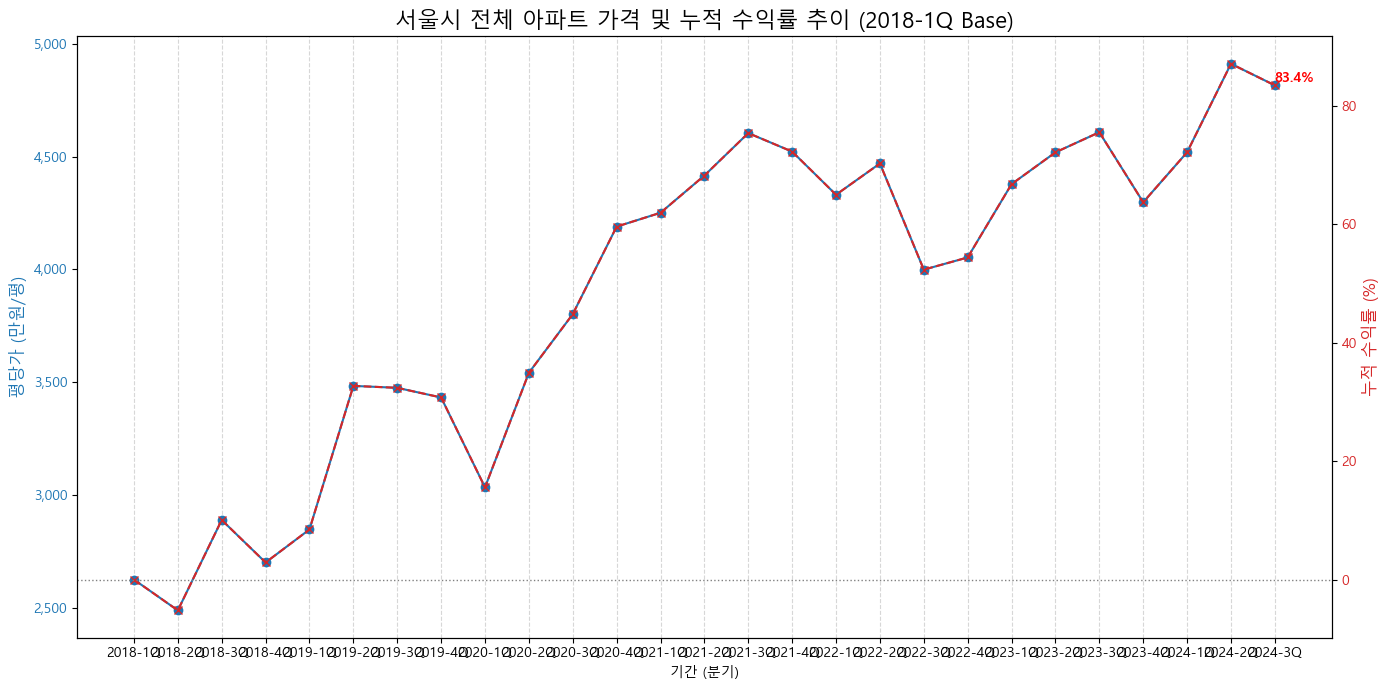

■ 서울시 전체 아파트 시장 흐름 요약
- 분석 기간: 27개 분기 (2018-1Q ~ 2024-3Q)
- 시작 평당가: 2,625 만원
- 종료 평당가: 4,815 만원
- 서울시 전체 누적 수익률: 83.43%


In [56]:
def visualize_seoul_total_trend(bldg_type, start_year, start_quarter, duration_quarters):
    # 1. 기간 생성
    period_list = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        period_list.append((current_y, current_q))
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
    
    target_years = sorted(list(set([y for y, q in period_list])))

    # 2. 데이터 필터링
    mask = (
        (df2['CTRT_YEAR'].isin(target_years)) & 
        (df2['BLDG_USG'] == bldg_type)
    )
    temp_df = df2.loc[mask].copy()
    
    # 시점 컬럼 생성 (Sorting을 위해 튜플 그대로 사용하거나 정렬 가능한 문자열 사용)
    # 여기서는 보기 좋게 문자열로 변환하되, 정렬은 period_list 순서대로 강제함
    temp_df['YR_Q_STR'] = temp_df['CTRT_YEAR'].astype(str) + '-' + temp_df['Quarter'].astype(str) + 'Q'
    
    # 3. 서울시 전체 평단가 집계 (산술평균)
    # 그룹핑: [연도, 분기] -> 전체 평단가 평균
    trend_series = temp_df.groupby(['CTRT_YEAR', 'Quarter'])['AMOUNT_PER_PYEONG'].mean()
    
    # 인덱스를 보기 좋은 문자열 리스트로 변환 및 필터링
    # 존재하는 기간만 남기기 위해 reindex 활용
    trend_df = pd.DataFrame(trend_series).reset_index()
    trend_df['Label'] = trend_df['CTRT_YEAR'].astype(str) + '-' + trend_df['Quarter'].astype(str) + 'Q'
    
    # 입력된 기간(period_list)에 해당하는 것만 순서대로 추출
    target_labels = [f"{y}-{q}Q" for y, q in period_list]
    trend_df = trend_df[trend_df['Label'].isin(target_labels)]
    
    # 순서 보장 (Merge or set_index)
    trend_df = trend_df.set_index('Label').reindex(target_labels).dropna()
    
    if trend_df.empty:
        print("데이터가 없습니다.")
        return

    # 4. 누적 수익률 계산
    start_price = trend_df['AMOUNT_PER_PYEONG'].iloc[0]
    trend_df['Return'] = (trend_df['AMOUNT_PER_PYEONG'] / start_price - 1) * 100
    
    # 5. 시각화 (이중축: 평단가 & 수익률)
    fig, ax1 = plt.subplots(figsize=(14, 7))
    
    # (1) 평단가 (Bar Chart or Line) - 여기선 흐름을 보기 위해 Line
    color_price = 'tab:blue'
    ax1.set_xlabel('기간 (분기)')
    ax1.set_ylabel('평당가 (만원/평)', color=color_price, fontsize=12)
    ax1.plot(trend_df.index, trend_df['AMOUNT_PER_PYEONG'], color=color_price, marker='o', label='평균 평당가')
    ax1.tick_params(axis='y', labelcolor=color_price)
    ax1.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    # 천단위 콤마
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

    # (2) 누적 수익률 (Line with Area)
    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
    color_ret = 'tab:red'
    ax2.set_ylabel('누적 수익률 (%)', color=color_ret, fontsize=12) 
    ax2.plot(trend_df.index, trend_df['Return'], color=color_ret, linestyle='--', marker='x', label='누적 수익률')
    ax2.tick_params(axis='y', labelcolor=color_ret)
    
    # 0% 기준선
    ax2.axhline(0, color='gray', linestyle=':', linewidth=1)
    
    # 수익률 값 텍스트 표시 (최고점, 최저점, 마지막점)
    # 마지막 점
    last_idx = trend_df.index[-1]
    last_val = trend_df['Return'].iloc[-1]
    ax2.text(last_idx, last_val, f"{last_val:.1f}%", color='red', fontweight='bold', va='bottom', ha='left')

    plt.title(f"서울시 전체 {bldg_type} 가격 및 누적 수익률 추이 ({target_labels[0]} Base)", fontsize=16)
    plt.xticks(rotation=45)
    
    fig.tight_layout()
    plt.show()
    
    # 결과 요약
    print(f"■ 서울시 전체 {bldg_type} 시장 흐름 요약")
    print(f"- 분석 기간: {len(trend_df)}개 분기 ({trend_df.index[0]} ~ {trend_df.index[-1]})")
    print(f"- 시작 평당가: {start_price:,.0f} 만원")
    print(f"- 종료 평당가: {trend_df['AMOUNT_PER_PYEONG'].iloc[-1]:,.0f} 만원")
    print(f"- 서울시 전체 누적 수익률: {last_val:.2f}%")

# 실행
visualize_seoul_total_trend("아파트", 2018, 1, 26)

C:\Users\gorhk\AppData\Local\Temp\ipykernel_52164\146030926.py:91: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


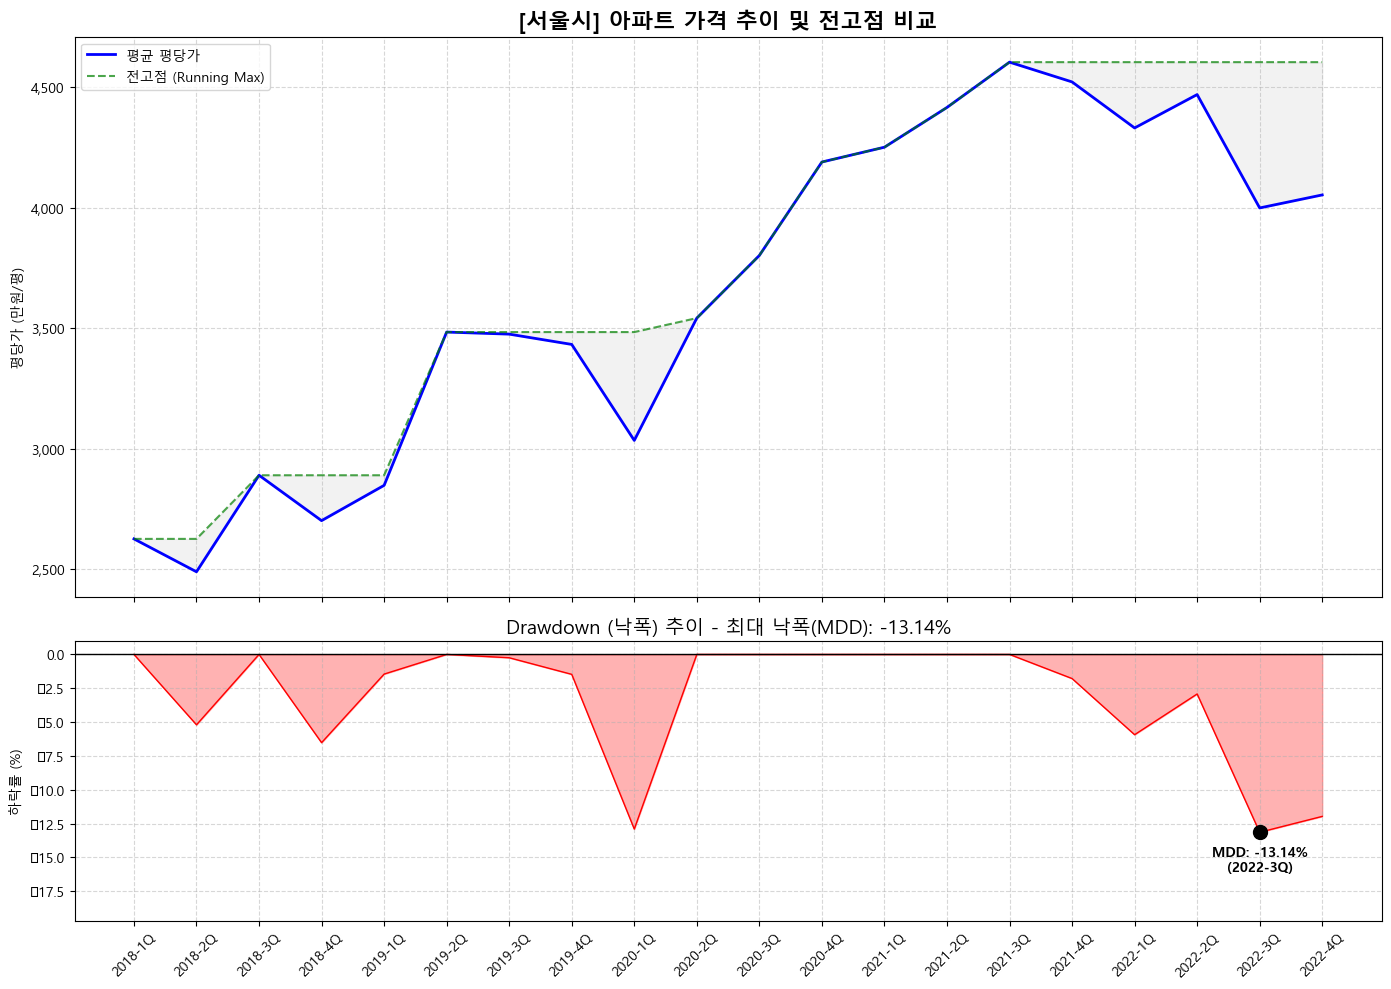

■ [서울시] 아파트 MDD 분석 결과
- 최대 낙폭(MDD): -13.14%
- MDD 발생 시점: 2022-3Q (전고점 4,604만원 대비)
- 현재 Drawdown: -11.97%


C:\Users\gorhk\AppData\Local\Temp\ipykernel_52164\146030926.py:91: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


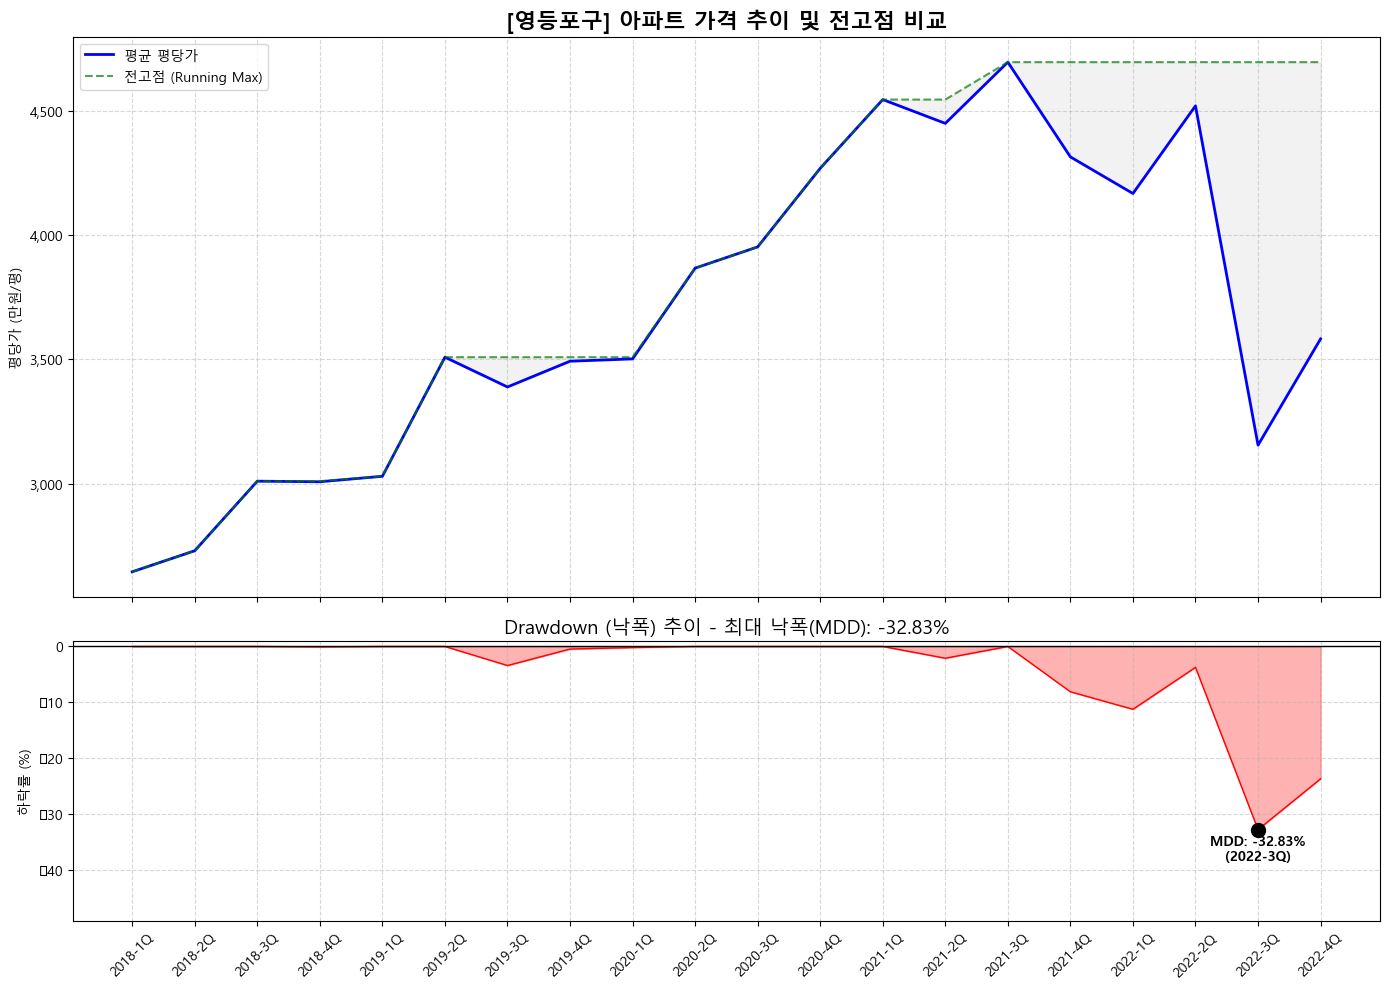

■ [영등포구] 아파트 MDD 분석 결과
- 최대 낙폭(MDD): -32.83%
- MDD 발생 시점: 2022-3Q (전고점 4,696만원 대비)
- 현재 Drawdown: -23.72%


In [63]:
def visualize_mdd(bldg_type, start_year, start_quarter, duration_quarters, region='서울시'):
    """
    지역(서울시 전체 또는 특정 자치구)의 아파트 가격 MDD를 시각화합니다.
    
    Parameters:
    - region: '서울시' (기본값) 또는 자치구명 (예: '강남구', '노원구')
    """
    
    # 1. 기간 및 데이터 설정
    period_list = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        period_list.append((current_y, current_q))
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    target_years = sorted(list(set([y for y, q in period_list])))
    
    # 데이터 조회 (마스크 설정)
    mask = (
        (df2['CTRT_YEAR'].isin(target_years)) & 
        (df2['BLDG_USG'] == bldg_type)
    )
    
    # [수정] 특정 자치구가 선택된 경우 조건 추가
    if region != '서울시':
        mask = mask & (df2['CGG_NM'] == region)

    temp_df = df2.loc[mask].copy()
    
    if temp_df.empty:
        print(f"[{region}] 해당 기간에 데이터가 없습니다.")
        return

    # 전처리: 시점 문자열 생성 및 평균 집계
    # 자치구를 선택했더라도, 해당 자치구 내의 평균을 구해야 하므로 로직은 동일
    temp_df['Quarter'] = temp_df['CTRT_DAY'].dt.quarter
    trend_series = temp_df.groupby(['CTRT_YEAR', 'Quarter'])['AMOUNT_PER_PYEONG'].mean()
    
    trend_df = pd.DataFrame(trend_series).reset_index()
    trend_df['Label'] = trend_df['CTRT_YEAR'].astype(str) + '-' + trend_df['Quarter'].astype(str) + 'Q'
    
    # 보고자 하는 기간만 필터링 및 인덱스 설정
    target_labels = [f"{y}-{q}Q" for y, q in period_list]
    trend_df = trend_df[trend_df['Label'].isin(target_labels)]
    trend_df = trend_df.set_index('Label').reindex(target_labels).dropna()
    
    if trend_df.empty:
        print(f"[{region}] 선택한 기간에 유효한 데이터가 충분하지 않습니다.")
        return

    # 2. MDD 계산 (Run Max 대비 현재가 하락률)
    trend_df['Run_Max'] = trend_df['AMOUNT_PER_PYEONG'].cummax()
    trend_df['Drawdown'] = (trend_df['AMOUNT_PER_PYEONG'] / trend_df['Run_Max'] - 1) * 100
    
    mdd_val = trend_df['Drawdown'].min()
    mdd_point = trend_df['Drawdown'].idxmin()

    # 3. 시각화
    fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    
    # (1) Upper Plot
    ax[0].plot(trend_df.index, trend_df['AMOUNT_PER_PYEONG'], label='평균 평당가', color='blue', linewidth=2)
    ax[0].plot(trend_df.index, trend_df['Run_Max'], label='전고점 (Running Max)', color='green', linestyle='--', alpha=0.7)
    ax[0].fill_between(trend_df.index, trend_df['AMOUNT_PER_PYEONG'], trend_df['Run_Max'], color='gray', alpha=0.1)
    
    ax[0].set_title(f"[{region}] {bldg_type} 가격 추이 및 전고점 비교", fontsize=16, fontweight='bold')
    ax[0].set_ylabel("평당가 (만원/평)")
    ax[0].legend(loc='upper left')
    ax[0].grid(True, linestyle='--', alpha=0.5)
    ax[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

    # (2) Lower Plot (Underwater)
    ax[1].fill_between(trend_df.index, trend_df['Drawdown'], 0, color='red', alpha=0.3)
    ax[1].plot(trend_df.index, trend_df['Drawdown'], color='red', linewidth=1)
    
    ax[1].scatter(mdd_point, mdd_val, color='black', s=100, zorder=5)
    ax[1].text(mdd_point, mdd_val - 1, f"MDD: {mdd_val:.2f}%\n({mdd_point})", 
               ha='center', va='top', fontweight='bold', color='black')
    
    ax[1].set_title(f"Drawdown (낙폭) 추이 - 최대 낙폭(MDD): {mdd_val:.2f}%", fontsize=14)
    ax[1].set_ylabel("하락률 (%)")
    ax[1].set_ylim(min(mdd_val * 1.5, -5), 1)
    ax[1].axhline(0, color='black', linewidth=1)
    ax[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 결과 요약
    print(f"■ [{region}] {bldg_type} MDD 분석 결과")
    print(f"- 최대 낙폭(MDD): {mdd_val:.2f}%")
    print(f"- MDD 발생 시점: {mdd_point} (전고점 {trend_df.loc[mdd_point, 'Run_Max']:,.0f}만원 대비)")
    print(f"- 현재 Drawdown: {trend_df['Drawdown'].iloc[-1]:.2f}%")

# --- 사용 예시 ---
# 1. 서울시 전체 보기 (기본값)
visualize_mdd("아파트", 2018, 1, 19)

# 2. 특정 자치구 보기 (예: 노원구)
visualize_mdd("아파트", 2018, 1, 19, region="영등포구")

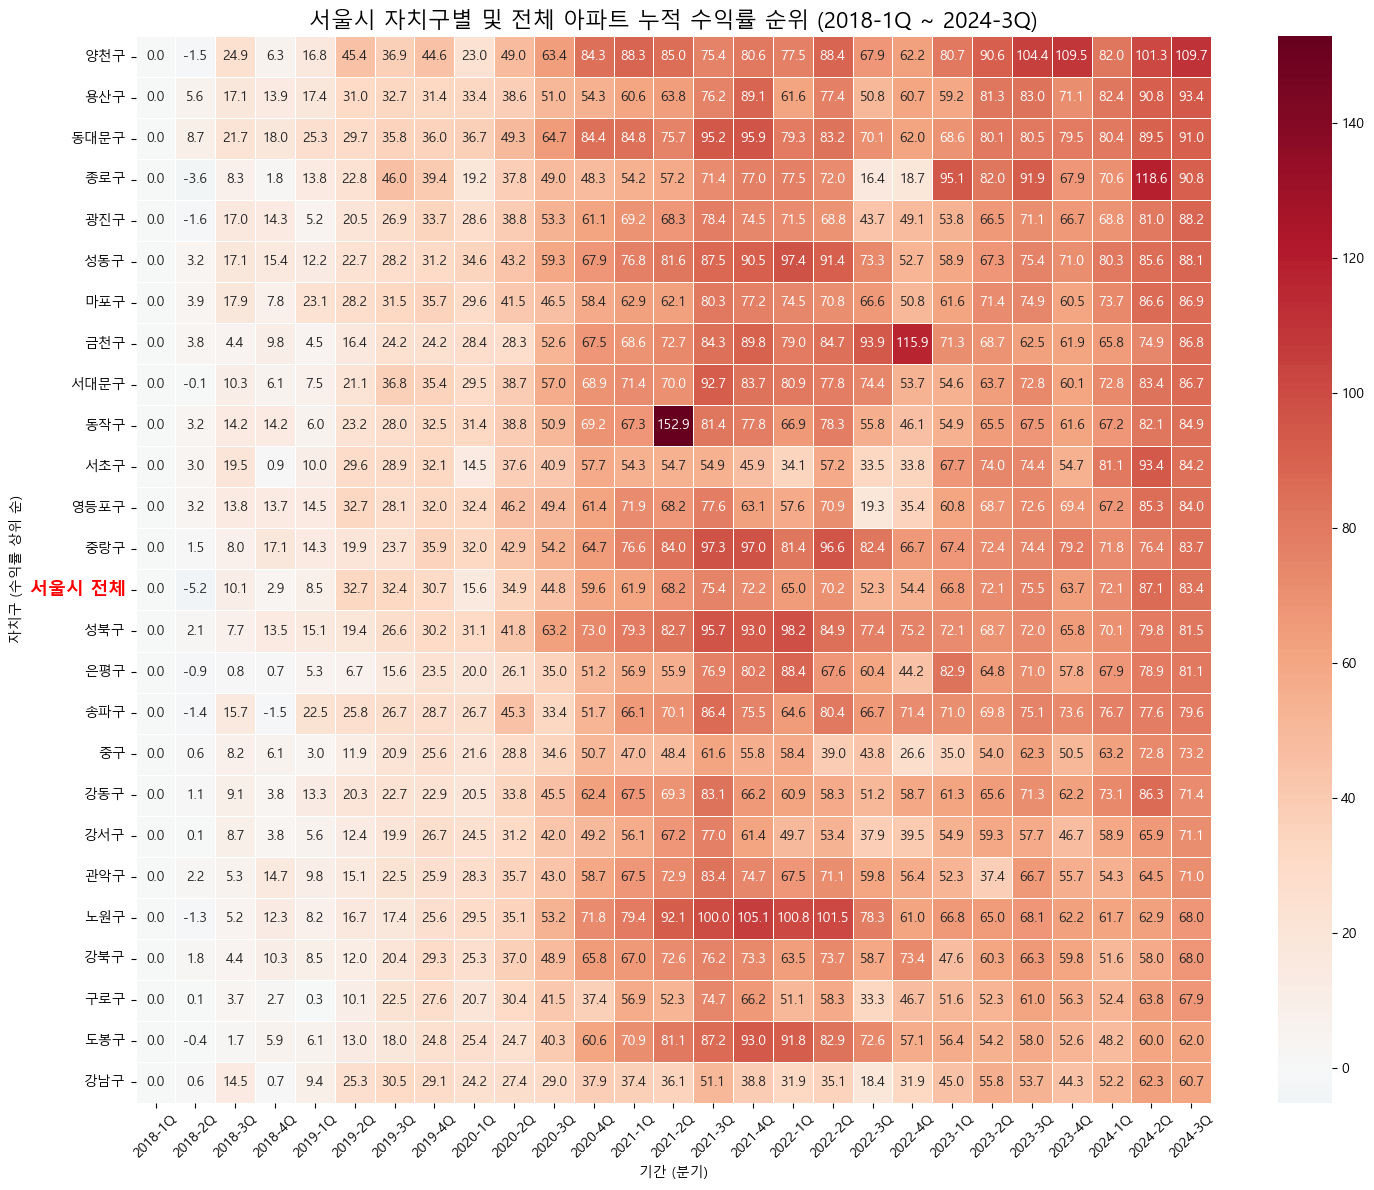

■ 최종 순위 요약 (총 26개)
1위. 양천구: 109.71%
2위. 용산구: 93.43%
3위. 동대문구: 91.05%
★ [14위] 서울시 전체: 83.43% (Average)
24위. 구로구: 67.89%
25위. 도봉구: 62.01%
26위. 강남구: 60.67%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_seoul_cagr_heatmap_ranked(bldg_type, start_year, start_quarter, duration_quarters):
    # 1. 기간 생성
    period_list = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        period_list.append((current_y, current_q))
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    target_years = sorted(list(set([y for y, q in period_list])))
    
    # 2. 데이터 추출
    mask = (
        (df2['CTRT_YEAR'].isin(target_years)) & 
        (df2['BLDG_USG'] == bldg_type) &
        (df2['CGG_NM'].notnull())
    )
    temp_df = df2.loc[mask].copy() 
    
    temp_df['YR_Q'] = temp_df['CTRT_YEAR'].astype(str) + '-' + temp_df['Quarter'].astype(str) + 'Q'
    target_period_strs = [f"{y}-{q}Q" for y, q in period_list]
    
    final_df = temp_df[temp_df['YR_Q'].isin(target_period_strs)].copy()
    
    if final_df.empty:
        print("데이터가 없습니다.")
        return

    # 3. [개별 자치구] 평단가 집계
    pivot_price = final_df.pivot_table(index='CGG_NM', columns='YR_Q', values='AMT_PER_PYEONG', aggfunc='mean')
    
    # 4. [서울시 전체] 평단가 집계
    seoul_series = final_df.groupby('YR_Q')['AMOUNT_PER_PYEONG'].mean()
    
    # 데이터 병합 전 컬럼 순서 맞추기
    valid_cols = [c for c in target_period_strs if c in pivot_price.columns]
    pivot_price = pivot_price[valid_cols]
    seoul_series = seoul_series.reindex(valid_cols)
    
    # 5. 수익률 계산
    # (1) 자치구 수익률
    base_prices = pivot_price.iloc[:, 0]
    growth_rate_df = pivot_price.div(base_prices, axis=0)
    growth_rate_df = (growth_rate_df - 1) * 100
    
    # (2) 서울시 전체 수익률
    seoul_ret = (seoul_series / seoul_series.iloc[0] - 1) * 100
    
    # [핵심] '서울시 전체'를 자치구와 동일한 레벨로 추가
    growth_rate_df.loc['서울시 전체'] = seoul_ret
    
    # 6. 전체 정렬 (최종 수익률 순)
    final_returns = growth_rate_df.iloc[:, -1]
    final_sorted_df = growth_rate_df.loc[final_returns.sort_values(ascending=False).index]
    
    # 7. Heatmap 시각화
    plt.figure(figsize=(15, 12))
    
    sns.heatmap(final_sorted_df, annot=True, fmt='.1f', cmap='RdBu_r', center=0, linewidths=0.5)
    
    plt.title(f"서울시 자치구별 및 전체 {bldg_type} 누적 수익률 순위 ({target_period_strs[0]} ~ {target_period_strs[-1]})", fontsize=16)
    plt.xlabel("기간 (분기)")
    plt.ylabel("자치구 (수익률 상위 순)")
    plt.xticks(rotation=45)
    
    # y축에서 '서울시 전체' 찾아서 강조(빨간색 Bold)
    ax = plt.gca()
    for tick in ax.get_yticklabels():
        if tick.get_text() == '서울시 전체':
            tick.set_color('red')
            tick.set_fontweight('heavy') # Bold보다 더 두껍게
            tick.set_fontsize(13)
        else:
            tick.set_color('black')
    
    plt.tight_layout()
    plt.show()
    
    # 순위 출력
    print(f"■ 최종 순위 요약 (총 {len(final_sorted_df)}개)")
    rank = 1
    for name in final_sorted_df.index:
        ret = final_sorted_df.loc[name].iloc[-1]
        if name == '서울시 전체':
            print(f"★ [{rank}위] {name}: {ret:.2f}% (Average)")
        else:
            if rank <= 3 or rank >= len(final_sorted_df)-2: # 상위 3개, 하위 3개만 출력
                print(f"{rank}위. {name}: {ret:.2f}%")
        rank += 1

# 실행
visualize_seoul_cagr_heatmap_ranked("아파트", 2018, 1, 26)

- 동작구 21년 2분기 드림캐슬 이상치 확인

- 22년 2~3분기 종로구의 폭락장

- 연도별, 분기별 거래량 추이

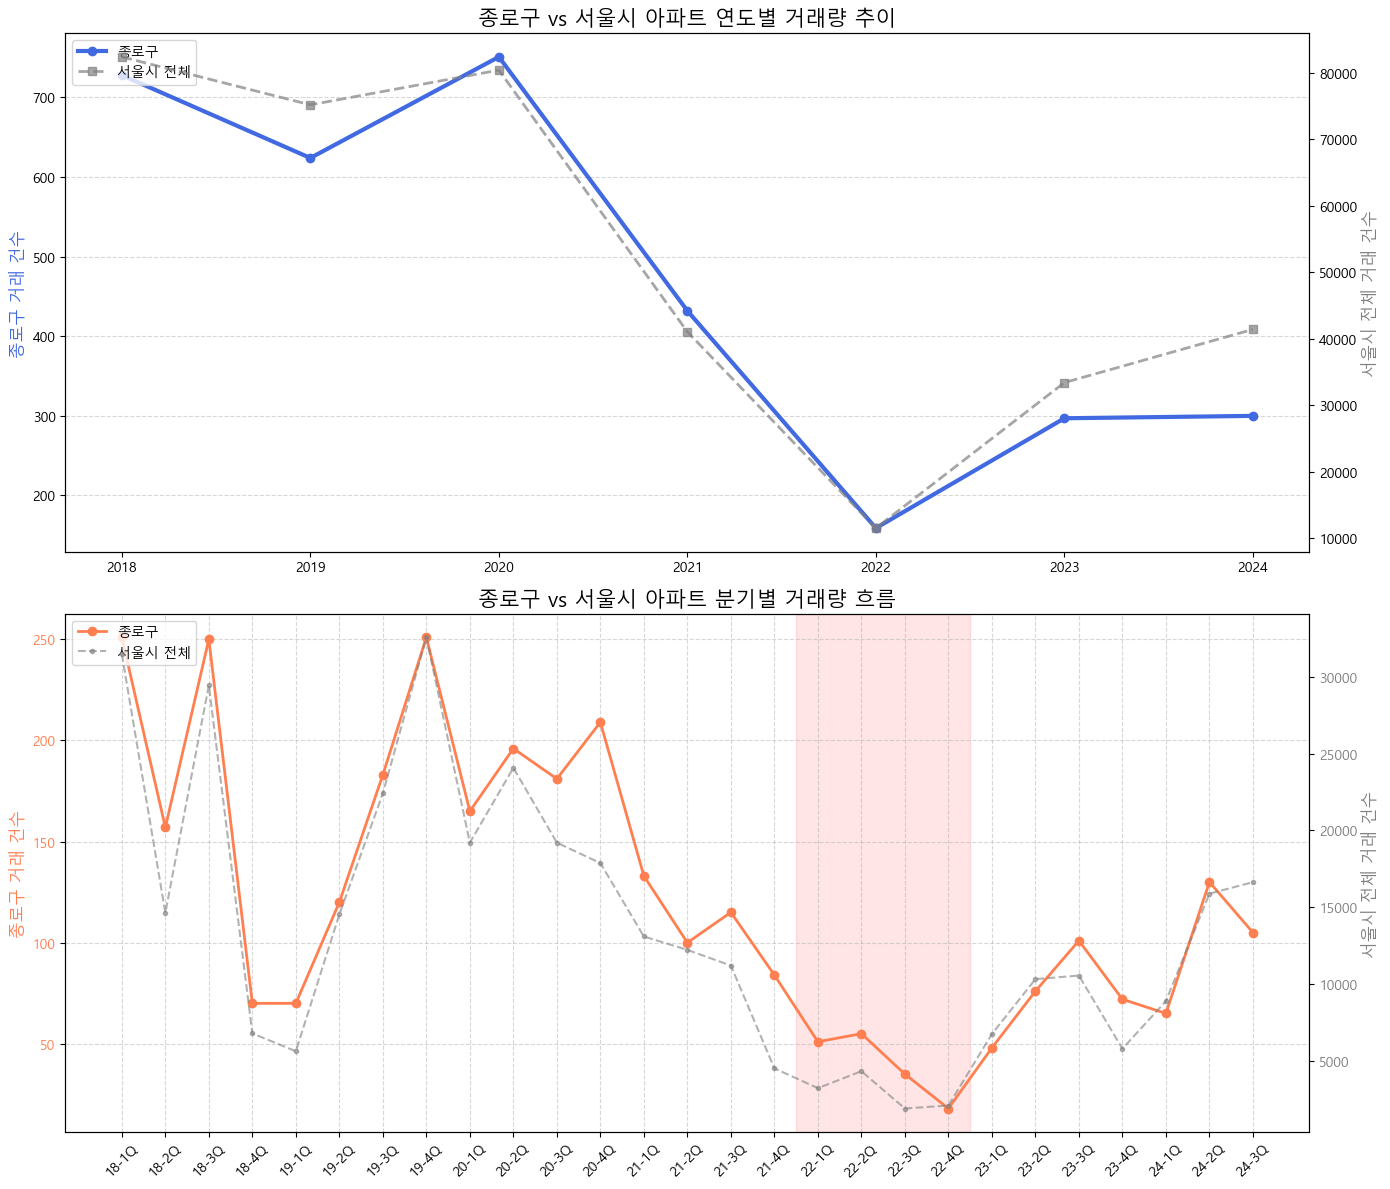

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def visualize_transaction_volume_vs_seoul(gu_name, bldg_type="아파트"):
    # 1. 데이터 준비
    # (1) 타겟 자치구
    mask_gu = (df2['CGG_NM'] == gu_name) & (df2['BLDG_USG'] == bldg_type)
    gu_df = df2.loc[mask_gu].copy()
    
    # (2) 서울시 전체 (비교군)
    mask_seoul = (df2['BLDG_USG'] == bldg_type)
    seoul_df = df2.loc[mask_seoul].copy()

    if gu_df.empty:
        print(f"{gu_name} {bldg_type} 데이터가 없습니다.")
        return

    # 2. 연도별 거래량 집계
    gu_yearly = gu_df.groupby('CTRT_YEAR').size()
    seoul_yearly = seoul_df.groupby('CTRT_YEAR').size()

    # 3. 분기별 거래량 집계
    seoul_quarterly = seoul_df.groupby(['CTRT_YEAR', 'Quarter']).size()
    gu_quarterly = gu_df.groupby(['CTRT_YEAR', 'Quarter']).size()
    
    # X축 라벨 생성 & 인덱스 리셋 (시계열 매칭)
    q_labels = [f"{str(y)[2:]}-{q}Q" for y, q in seoul_quarterly.index] # 22-1Q 형태로 짧게
    
    gu_quarterly = gu_quarterly.reindex(seoul_quarterly.index, fill_value=0)
    
    # 4. 시각화
    fig, ax = plt.subplots(2, 1, figsize=(14, 12))

    # --- (1) 연도별 Line Chart ---
    # [수정] Bar -> Line
    # X축이 숫자형(연도)이므로 그대로 사용 가능
    line_y1 = ax[0].plot(gu_yearly.index, gu_yearly.values, marker='o', color='royalblue', linewidth=3, label=f'{gu_name}')
    ax[0].set_ylabel(f"{gu_name} 거래 건수", color='royalblue', fontsize=12)
    ax[0].grid(axis='y', linestyle='--', alpha=0.5)
    
    # 오른쪽 축: 서울시 전체 (Line)
    ax0_twin = ax[0].twinx()
    line_y2 = ax0_twin.plot(seoul_yearly.index, seoul_yearly.values, color='gray', marker='s', linestyle='--', linewidth=2, alpha=0.7, label='서울시 전체')
    ax0_twin.set_ylabel("서울시 전체 거래 건수", color='gray', fontsize=12)
    
    # X축 정수만 표시
    ax[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    
    ax[0].set_title(f"{gu_name} vs 서울시 {bldg_type} 연도별 거래량 추이", fontsize=15)
    
    # 범례 합치기
    lines_y = line_y1 + line_y2
    labels_y = [l.get_label() for l in lines_y]
    ax[0].legend(lines_y, labels_y, loc='upper left')

    # --- (2) 분기별 Line Chart ---
    x_range = range(len(q_labels))
    line_q1 = ax[1].plot(x_range, gu_quarterly.values, marker='o', color='coral', linewidth=2, label=f'{gu_name}')
    ax[1].set_ylabel(f"{gu_name} 거래 건수", color='coral', fontsize=12)
    ax[1].tick_params(axis='y', labelcolor='coral')
    
    # 오른쪽 축: 서울시 전체
    ax1_twin = ax[1].twinx()
    line_q2 = ax1_twin.plot(x_range, seoul_quarterly.values, marker='.', color='gray', linestyle='--', alpha=0.6, label='서울시 전체')
    ax1_twin.set_ylabel("서울시 전체 거래 건수", color='gray', fontsize=12)
    ax1_twin.tick_params(axis='y', labelcolor='gray')
    
    # X축 설정
    ax[1].set_xticks(x_range)
    ax[1].set_xticklabels(q_labels, rotation=45)
    ax[1].set_title(f"{gu_name} vs 서울시 {bldg_type} 분기별 거래량 흐름", fontsize=15)
    ax[1].grid(True, linestyle='--', alpha=0.5)
    
    # 2022년 하락장 구간 강조 (배경색)
    indices_2022 = [i for i, label in enumerate(q_labels) if '22' in label]
    if indices_2022:
        ax[1].axvspan(indices_2022[0]-0.5, indices_2022[-1]+0.5, color='red', alpha=0.1, label='2022년(하락장)')

    # 범례 표시
    lines_q = line_q1 + line_q2
    labels_q = [l.get_label() for l in lines_q]
    ax[1].legend(lines_q, labels_q, loc='upper left')

    plt.tight_layout()
    plt.show()

# 사용 예시
visualize_transaction_volume_vs_seoul("종로구")

In [37]:
# 1. 쿼리 조건 설정
target_year = 2022
target_quarters = [2, 3, 4]
target_gu = ['종로구', '영등포구', '노원구']

# Quarter 컬럼이 혹시 없다면 생성
if 'Quarter' not in df2.columns:
    df2['Quarter'] = df2['CTRT_DAY'].dt.quarter

# 2. 데이터 필터링
condition = (
    (df2['CTRT_YEAR'] == target_year) &
    (df2['Quarter'].isin(target_quarters)) &
    (df2['CGG_NM'].isin(target_gu)) &
    (df2['BLDG_USG'] == '아파트')
)

# 3. 결과 집계 (행: 자치구, 열: 분기)
volume_result = df2[condition].groupby(['CGG_NM', 'Quarter']).size().unstack(fill_value=0)

print("=== 2022년 아파트 분기별 거래량 (2~4분기) ===")
display(volume_result)

=== 2022년 아파트 분기별 거래량 (2~4분기) ===


Quarter,2,3,4
CGG_NM,,,
노원구,313,118,145
영등포구,226,135,128
종로구,55,35,18


c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
c:\Users\gorhk\DA_Portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


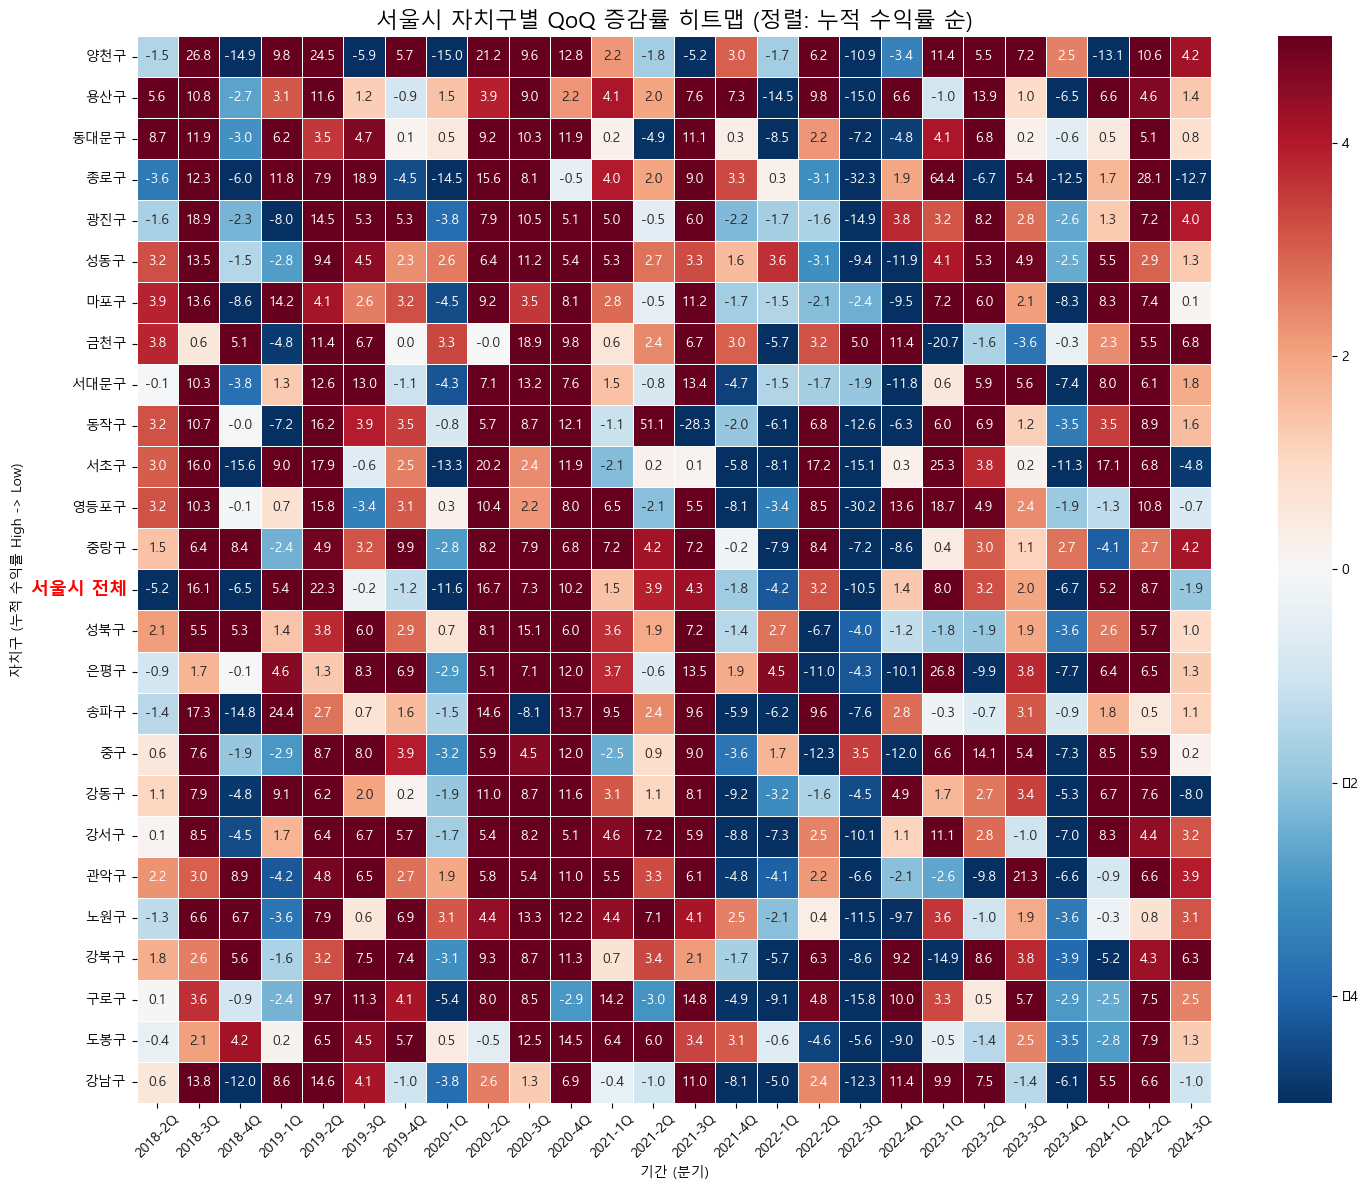

■ 누적 수익률 1위: 양천구 (109.71%)
■ 서울시 전체 누적 수익률: 83.43%


In [ ]:
def visualize_seoul_qoq_heatmap_cum_sorted(bldg_type, start_year, start_quarter, duration_quarters):
    # 1. 기간 설정
    period_list = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        period_list.append((current_y, current_q))
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    target_years = sorted(list(set([y for y, q in period_list])))
    
    # 2. 데이터 추출
    mask = (
        (df2['CTRT_YEAR'].isin(target_years)) & 
        (df2['BLDG_USG'] == bldg_type) &
        (df2['CGG_NM'].notnull())
    )
    temp_df = df2.loc[mask].copy()
    
    temp_df['YR_Q'] = temp_df['CTRT_YEAR'].astype(str) + '-' + temp_df['Quarter'].astype(str) + 'Q'
    target_period_strs = [f"{y}-{q}Q" for y, q in period_list]
    
    final_df = temp_df[temp_df['YR_Q'].isin(target_period_strs)].copy()
    
    if final_df.empty:
        print("데이터가 없습니다.")
        return

    # 3. 평단가 집계
    # (1) [개별 자치구]
    pivot_price = final_df.pivot_table(index='CGG_NM', columns='YR_Q', values='AMOUNT_PER_PYEONG', aggfunc='mean')
    
    # (2) [서울시 전체]
    seoul_series = final_df.groupby('YR_Q')['AMOUNT_PER_PYEONG'].mean()
    
    # 컬럼 순서 및 인덱스 맞추기
    valid_cols = [c for c in target_period_strs if c in pivot_price.columns]
    pivot_price = pivot_price[valid_cols]
    seoul_series = seoul_series.reindex(valid_cols)
    
    # 4. QoQ (전분기 대비 증감률) 계산 -> 히트맵 색칠용
    qoq_df = pivot_price.pct_change(axis=1) * 100
    qoq_seoul = seoul_series.pct_change() * 100
    
    qoq_df.loc['서울시 전체'] = qoq_seoul
    qoq_df = qoq_df.iloc[:, 1:] # 첫 분기 제외
    
    # 5. [핵심] 정렬 기준: 누적 수익률 (전체 기간)
    # (마지막 가격 / 시작 가격 - 1)
    
    # (1) 자치구 누적 수익률
    dist_cum_ret = (pivot_price.iloc[:, -1] / pivot_price.iloc[:, 0] - 1) * 100
    
    # (2) 서울시 전체 누적 수익률
    seoul_cum_ret = (seoul_series.iloc[-1] / seoul_series.iloc[0] - 1) * 100
    
    # 합쳐서 정렬용 Series 생성
    dist_cum_ret['서울시 전체'] = seoul_cum_ret
    
    # 누적 수익률 높은 순서로 정렬된 인덱스 추출
    sorted_indices = dist_cum_ret.sort_values(ascending=False).index
    
    # QoQ 데이터프레임을 이 순서대로 재정렬
    final_sorted_df = qoq_df.loc[sorted_indices]
    
    if final_sorted_df.empty:
        print("비교할 기간이 충분하지 않습니다.")
        return

    # 6. Heatmap 시각화
    plt.figure(figsize=(15, 12))
    
    sns.heatmap(final_sorted_df, annot=True, fmt='.1f', cmap='RdBu_r', center=0, linewidths=0.5, vmin=-5, vmax=5)
    
    plt.title(f"서울시 자치구별 QoQ 증감률 히트맵 (정렬: 누적 수익률 순)", fontsize=16)
    plt.xlabel("기간 (분기)")
    plt.ylabel("자치구 (누적 수익률 High -> Low)")
    plt.xticks(rotation=45)
    
    # '서울시 전체' 라벨 강조
    ax = plt.gca()
    for tick in ax.get_yticklabels():
        if tick.get_text() == '서울시 전체':
            tick.set_color('red')
            tick.set_fontweight('heavy')
            tick.set_fontsize(13)
        else:
            tick.set_color('black')
            
    plt.tight_layout()
    plt.show()
    
    # 상위 1등과 서울 평균 출력
    top_1 = sorted_indices[0]
    top_val = dist_cum_ret[top_1]
    print(f"■ 누적 수익률 1위: {top_1} ({top_val:.2f}%)")
    print(f"■ 서울시 전체 누적 수익률: {seoul_cum_ret:.2f}%")

# 실행
visualize_seoul_qoq_heatmap_cum_sorted("아파트", 2018, 1, 27)

      [종로구 vs 서울시 전체] 아파트 투자 백테스트 비교
1. 투자 기간 : 2022-2Q ~ 2024-3Q (10분기)
2. 매입 금액 : 10.0억 원
----------------------------------------------------------------
   구분        |      종로구      |     서울시 전체
----------------------------------------------------------------
3. 최종 금액   |  11.09억 (+1.09억) |  10.77억 (+0.77억)
4. 누적 수익률 |      10.91 %       |       7.75 %
5. CAGR (연)   |       4.23 %       |       3.03 %
6. MDD (낙폭)  |     -32.33 %       |     -10.53 %
----------------------------------------------------------------
 * 비교 결과: 종로구 수익률이 서울 평균보다 높음



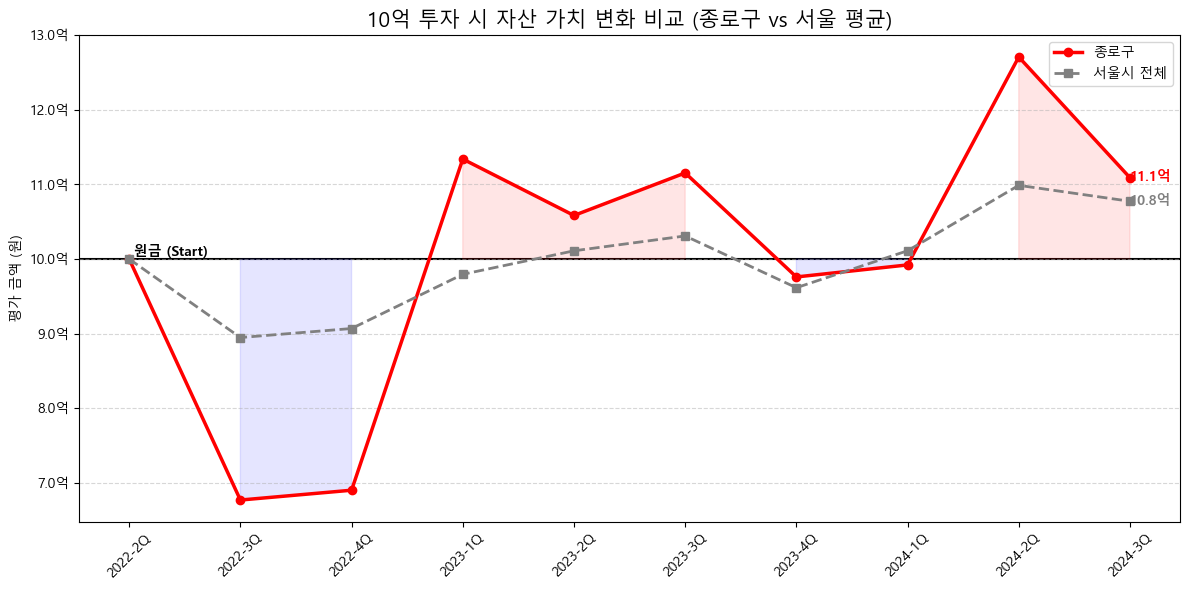

In [ ]:
def run_real_estate_backtest_vs_seoul(target_gu, bldg_type, start_year, start_quarter, initial_capital, duration_quarters):
    # 1. 기간 설정
    period_list = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        period_list.append((current_y, current_q))
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    target_years = sorted(list(set([y for y, q in period_list])))
    target_labels = [f"{y}-{q}Q" for y, q in period_list]
    
    # 2. 데이터 추출
    # (1) 타겟 자치구
    mask_gu = (
        (df2['CTRT_YEAR'].isin(target_years)) & 
        (df2['BLDG_USG'] == bldg_type) &
        (df2['CGG_NM'] == target_gu)
    )
    df_gu = df2.loc[mask_gu].copy()
    
    # (2) 서울시 전체 (비교군)
    mask_seoul = (
        (df2['CTRT_YEAR'].isin(target_years)) & 
        (df2['BLDG_USG'] == bldg_type)
    )
    df_seoul = df2.loc[mask_seoul].copy()
    
    if df_gu.empty or df_seoul.empty:
        print("데이터가 부족합니다.")
        return

    # 공통 전처리 함수
    def get_price_series(temp_df, group_cols):
        temp_df['YR_Q_STR'] = temp_df['CTRT_YEAR'].astype(str) + '-' + temp_df['Quarter'].astype(str) + 'Q'
        series = temp_df.groupby(['CTRT_YEAR', 'Quarter'])['AMOUNT_PER_PYEONG'].mean()
        pdf = pd.DataFrame(series).reset_index()
        pdf['Label'] = pdf['CTRT_YEAR'].astype(str) + '-' + pdf['Quarter'].astype(str) + 'Q'
        pdf = pdf[pdf['Label'].isin(target_labels)]
        pdf = pdf.set_index('Label').reindex(target_labels).dropna()
        return pdf

    price_gu = get_price_series(df_gu, ['CTRT_YEAR', 'Quarter'])
    price_seoul = get_price_series(df_seoul, ['CTRT_YEAR', 'Quarter'])
    
    # 데이터가 중간에 끊겼으면 자르기 (교집합 기간만 비교)
    common_idx = price_gu.index.intersection(price_seoul.index)
    price_gu = price_gu.loc[common_idx]
    price_seoul = price_seoul.loc[common_idx]
    
    # 3. 자산 가치 변동 및 지표 계산 함수
    def calc_metrics(price_df, capital):
        start_p = price_df['AMOUNT_PER_PYEONG'].iloc[0]
        portfolio = (price_df['AMOUNT_PER_PYEONG'] / start_p) * capital
        
        final_val = portfolio.iloc[-1]
        ret = (final_val / capital - 1) * 100
        
        years = len(portfolio) / 4
        cagr = ((final_val / capital) ** (1/years) - 1) * 100
        
        # MDD
        run_max = portfolio.cummax()
        dd = (portfolio / run_max - 1) * 100
        mdd = dd.min()
        
        # Best/Worst Year (단순화: 1년 4분기 전 대비 변동률 중 Max/Min)
        if len(portfolio) >= 5:
            # YoY (전년 동기 대비) Rolling
            yoy = portfolio.pct_change(4) * 100
            best_y = yoy.max()
            worst_y = yoy.min()
        else:
            best_y, worst_y = 0, 0
            
        return portfolio, final_val, ret, cagr, mdd, best_y, worst_y

    # 계산
    pf_gu, val_gu, ret_gu, cagr_gu, mdd_gu, best_gu, worst_gu = calc_metrics(price_gu, initial_capital)
    pf_seoul, val_seoul, ret_seoul, cagr_seoul, mdd_seoul, best_seoul, worst_seoul = calc_metrics(price_seoul, initial_capital)
    
    profit_gu = val_gu - initial_capital
    profit_seoul = val_seoul - initial_capital
    
    # --- [결과 텍스트 출력] ---
    print(f"================================================================")
    print(f"      [{target_gu} vs 서울시 전체] {bldg_type} 투자 백테스트 비교")
    print(f"================================================================")
    print(f"1. 투자 기간 : {common_idx[0]} ~ {common_idx[-1]} ({len(common_idx)}분기)")
    print(f"2. 매입 금액 : {initial_capital/100000000:.1f}억 원")
    print(f"----------------------------------------------------------------")
    print(f"   구분        |      {target_gu}      |     서울시 전체")
    print(f"----------------------------------------------------------------")
    print(f"3. 최종 금액   |  {val_gu/100000000:.2f}억 (+{profit_gu/100000000:.2f}억) |  {val_seoul/100000000:.2f}억 (+{profit_seoul/100000000:.2f}억)")
    print(f"4. 누적 수익률 |     {ret_gu:6.2f} %       |     {ret_seoul:6.2f} %")
    print(f"5. CAGR (연)   |     {cagr_gu:6.2f} %       |     {cagr_seoul:6.2f} %")
    print(f"6. MDD (낙폭)  |     {mdd_gu:6.2f} %       |     {mdd_seoul:6.2f} %")
    print(f"----------------------------------------------------------------")
    print(f" * 비교 결과: {target_gu} 수익률이 서울 평균보다 {'높음' if ret_gu > ret_seoul else '낮음'}")
    print(f"================================================================\n")
    
    # --- [시각화] ---
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # (1) 데이터 플로팅
    ax.plot(pf_gu.index, pf_gu, color='red', linewidth=2.5, marker='o', label=f'{target_gu}')
    ax.plot(pf_seoul.index, pf_seoul, color='gray', linewidth=2, linestyle='--', marker='s', label='서울시 전체')
    
    # (2) 기준선 (원금) 강조 -> 'y축의 0을 원금으로 대체' 효과
    # 실제 Y축 값을 바꾸기보다, 원금 선을 X축처럼 굵게 그림
    ax.axhline(initial_capital, color='black', linewidth=1.5, linestyle='-', zorder=1)
    ax.text(pf_gu.index[0], initial_capital, " 원금 (Start)", va='bottom', fontweight='bold')
    
    # (3) 영역 채우기 (원금 기준 수익/손실)
    ax.fill_between(pf_gu.index, pf_gu, initial_capital, where=(pf_gu >= initial_capital), color='red', alpha=0.1)
    ax.fill_between(pf_gu.index, pf_gu, initial_capital, where=(pf_gu < initial_capital), color='blue', alpha=0.1)
    
    ax.set_title(f"10억 투자 시 자산 가치 변화 비교 ({target_gu} vs 서울 평균)", fontsize=15)
    ax.set_ylabel("평가 금액 (원)")
    
    # Y축 포맷 (억 단위)
    def billions(x, pos):
        return f'{x*1e-8:.1f}억'
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(billions))
    
    # 최종 금액 라벨링
    ax.text(pf_gu.index[-1], pf_gu.iloc[-1], f"{pf_gu.iloc[-1]/1e8:.1f}억", color='red', fontweight='bold', ha='left', va='center')
    ax.text(pf_seoul.index[-1], pf_seoul.iloc[-1], f"{pf_seoul.iloc[-1]/1e8:.1f}억", color='gray', fontweight='bold', ha='left', va='center')

    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 실행
run_real_estate_backtest_vs_seoul("종로구", "아파트", 2022, 2, 1000000000, 10)

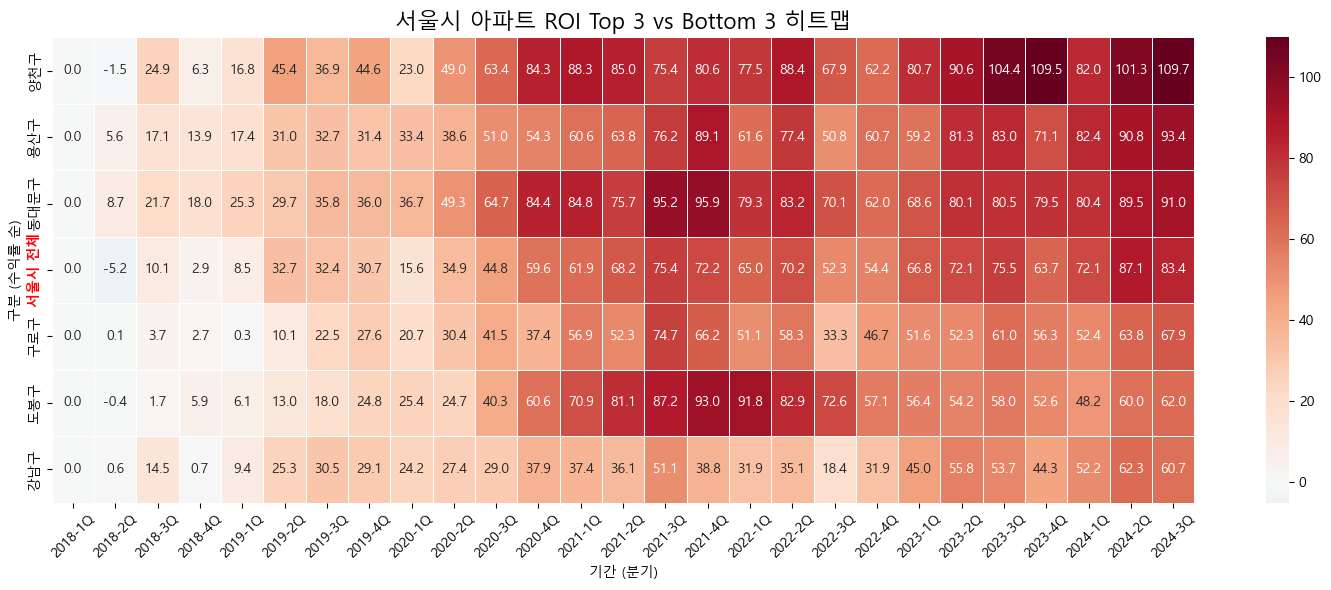

In [ ]:
def visualize_roi_top3_bottom3_heatmap(bldg_type, start_year, start_quarter, duration_quarters):
    # 1. 기간 생성
    period_list = []
    current_y, current_q = start_year, start_quarter
    for _ in range(duration_quarters + 1):
        period_list.append((current_y, current_q))
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    target_years = sorted(list(set([y for y, q in period_list])))
    
    # 2. 데이터 추출
    mask = (
        (df2['CTRT_YEAR'].isin(target_years)) & 
        (df2['BLDG_USG'] == bldg_type) &
        (df2['CGG_NM'].notnull())
    )
    temp_df = df2.loc[mask].copy()
    
    temp_df['YR_Q'] = temp_df['CTRT_YEAR'].astype(str) + '-' + temp_df['Quarter'].astype(str) + 'Q'
    target_period_strs = [f"{y}-{q}Q" for y, q in period_list]
    
    final_df = temp_df[temp_df['YR_Q'].isin(target_period_strs)].copy()
    
    if final_df.empty:
        print("데이터가 없습니다.")
        return

    # 3. 평단가 집계 & 수익률 계산
    # (1) 개별 자치구
    pivot_price = final_df.pivot_table(index='CGG_NM', columns='YR_Q', values='AMOUNT_PER_PYEONG', aggfunc='mean')
    
    # (2) 서울시 전체 Benchmark
    seoul_series = final_df.groupby('YR_Q')['AMOUNT_PER_PYEONG'].mean()
    
    # 컬럼 순서 맞추기
    valid_cols = [c for c in target_period_strs if c in pivot_price.columns]
    pivot_price = pivot_price[valid_cols]
    seoul_series = seoul_series.reindex(valid_cols)
    
    # 자치구 수익률 (Spread)
    base_prices = pivot_price.iloc[:, 0]
    growth_rate_df = pivot_price.div(base_prices, axis=0)
    growth_rate_df = (growth_rate_df - 1) * 100
    
    # 서울시 수익률
    seoul_ret = (seoul_series / seoul_series.iloc[0] - 1) * 100
    
    # 4. Top 3 / Bottom 3 필터링
    # 최종 수익률 기준 정렬
    final_returns = growth_rate_df.iloc[:, -1].sort_values(ascending=False)
    
    top3 = final_returns.head(3).index.tolist()
    bottom3 = final_returns.tail(3).index.tolist()
    
    # 데이터 추출
    top3_df = growth_rate_df.loc[top3]
    bottom3_df = growth_rate_df.loc[bottom3]
    seoul_df = pd.DataFrame(seoul_ret).T
    seoul_df.index = ['서울시 전체']
    
    # 병합: Top 3 -> 서울시 -> Bottom 3 순서
    final_sorted_df = pd.concat([top3_df, seoul_df, bottom3_df])
    
    # 5. 시각화
    plt.figure(figsize=(15, 6)) # 세로 길이를 줄여서 컴팩트하게
    
    sns.heatmap(final_sorted_df, annot=True, fmt='.1f', cmap='RdBu_r', center=0, linewidths=0.5)
    
    plt.title(f"서울시 {bldg_type} ROI Top 3 vs Bottom 3 히트맵", fontsize=16)
    plt.xlabel("기간 (분기)")
    plt.ylabel("구분 (수익률 순)")
    plt.xticks(rotation=45)
    
    # '서울시 전체' 강조 (빨간 글씨)
    ax = plt.gca()
    for tick in ax.get_yticklabels():
        if tick.get_text() == '서울시 전체':
            tick.set_color('red')
            tick.set_fontweight('bold')
            
    plt.tight_layout()
    plt.show()

# 실행
visualize_roi_top3_bottom3_heatmap("아파트", 2018, 1, 26)

In [44]:
df2.shape

(777307, 23)

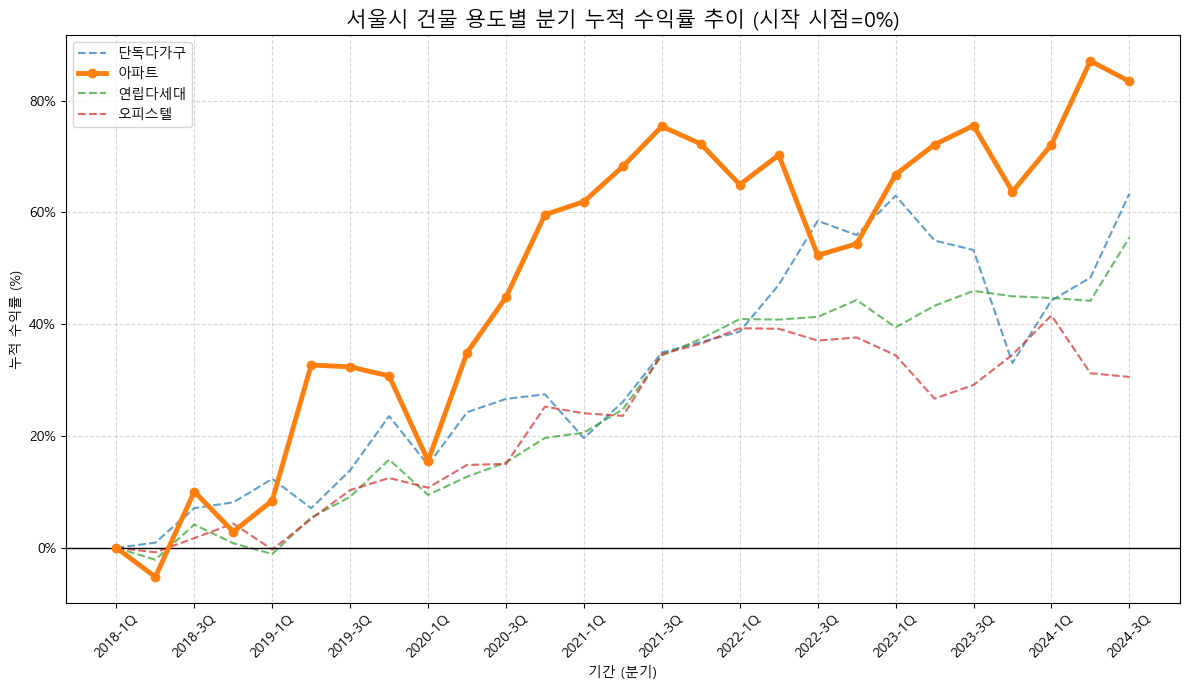

=== 기간 내 최종 누적 수익률 ===
BLDG_USG
아파트      +83.43%
단독다가구    +63.35%
연립다세대    +55.51%
오피스텔     +30.56%
Name: (2024, 3), dtype: object


In [45]:
## 건물 용도 별 ROI 추이

# 1. 데이터 준비 (분기 컬럼 확인)
if 'Quarter' not in df2.columns:
    df2['Quarter'] = df2['CTRT_DAY'].dt.quarter

if 'AMOUNT_PER_PYEONG' not in df2.columns:
    df2['AMOUNT_PER_PYEONG'] = (df2['THING_AMT'] / df2['ARCH_AREA']) * 3.3058

# 2. 건물 용도별, 연도-분기별 평균 평당가 집계
# 서울시 전체 기준이므로 자치구(CGG_NM) 구분 없이 집계
trend_df = df2.groupby(['BLDG_USG', 'CTRT_YEAR', 'Quarter'])['AMOUNT_PER_PYEONG'].mean().unstack(level=0)

# 시계열 순서가 섞이지 않게 정렬
trend_df = trend_df.sort_index()

# 3. 누적 수익률 계산 (Cumulative Return)
# (현재가 - 시작가) / 시작가 * 100
# 시작점(첫 데이터)을 기준(0%)으로 잡습니다.
cumulative_return = trend_df.apply(lambda x: (x / x.iloc[0] - 1) * 100)

# 4. 시각화
plt.figure(figsize=(12, 7))

# X축 라벨 생성 (2018-1Q 형태)
x_labels = [f"{y}-{q}Q" for y, q in cumulative_return.index]

# 각 건물 용도별로 선 그리기
for col in cumulative_return.columns:
    # 아파트는 중요하니 굵고 진하게 강조
    if col == '아파트':
        plt.plot(range(len(x_labels)), cumulative_return[col], label=col, linewidth=3.5, marker='o', zorder=10)
    else:
        plt.plot(range(len(x_labels)), cumulative_return[col], label=col, linewidth=1.5, linestyle='--', alpha=0.7)

# 5. 그래프 꾸미기
plt.title('서울시 건물 용도별 분기 누적 수익률 추이 (시작 시점=0%)', fontsize=15)
plt.ylabel('누적 수익률 (%)')
plt.xlabel('기간 (분기)')

# X축 라벨 설정 (너무 빽빽하지 않게 2분기 간격으로 표시 예시)
plt.xticks(range(0, len(x_labels), 2), x_labels[::2], rotation=45)

# 기준선(0%) 표시
plt.axhline(0, color='black', linewidth=1, linestyle='-')
plt.grid(True, linestyle='--', alpha=0.5)

# Y축 % 포맷
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

plt.legend()
plt.tight_layout()
plt.show()

# 최종 수익률 출력
print("=== 기간 내 최종 누적 수익률 ===")
print(cumulative_return.iloc[-1].sort_values(ascending=False).apply(lambda x: f"{x:+.2f}%"))

In [46]:
trend_df

BLDG_USG           단독다가구  아파트  연립다세대  오피스텔
CTRT_YEAR Quarter                         
2018      1         2089 2625   1811  2071
          2         2108 2489   1772  2054
          3         2237 2889   1886  2107
          4         2259 2701   1826  2161
2019      1         2346 2847   1791  2064
          2         2237 3484   1909  2178
          3         2379 3475   1976  2284
          4         2581 3432   2097  2329
2020      1         2398 3034   1982  2293
          2         2595 3542   2041  2378
          3         2645 3802   2087  2381
          4         2662 4189   2167  2593
2021      1         2498 4251   2184  2569
          2         2634 4416   2259  2559
          3         2819 4604   2434  2788
          4         2857 4522   2487  2826
2022      1         2897 4331   2552  2884
          2         3071 4469   2550  2882
          3         3310 3999   2559  2838
          4         3257 4053   2613  2850
2023      1         3404 4378   2525  2784
          2         3237 4519   2595  2623
          3         3201 4608   2643  2674
          4         2779 4297   2625  2786
2024      1         3013 4519   2620  2931
          2         3098 4911   2611  2717
          3         3412 4815   2816  2703

In [47]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777307 entries, 0 to 833598
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   RCPT_YR                777307 non-null  int64         
 1   CGG_CD                 777307 non-null  object        
 2   CGG_NM                 777307 non-null  object        
 3   STDG_CD                777307 non-null  object        
 4   STDG_NM                777307 non-null  object        
 5   LOTNO_SE_NM            724927 non-null  object        
 6   MNO                    724934 non-null  float64       
 7   SNO                    724934 non-null  float64       
 8   BLDG_NM                724951 non-null  object        
 9   CTRT_DAY               777307 non-null  datetime64[ns]
 10  THING_AMT              777307 non-null  int64         
 11  ARCH_AREA              777307 non-null  float64       
 12  LAND_AREA              617714 non-null  float64  